In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import zipfile
import os
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
zip_path = r"C:\Users\HP\Downloads\caltech101.zip"
extract_path = r"C:\Users\HP\Downloads\caltech101_extracted"

# Extract only once
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [9]:
import os

# Correct path based on your structure
data_dir = r"C:\Users\HP\Downloads\caltech101_extracted\caltech-101"

print("Checking dataset folder:")
print(os.listdir(data_dir)[:10])  # should show class folders like yin_yang, soccer_ball

Checking dataset folder:
['accordion', 'airplanes', 'anchor', 'ant', 'BACKGROUND_Google', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai']


In [10]:
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

class_names = dataset.class_names
num_classes = len(class_names)

print("Classes:", num_classes)

Found 9144 files belonging to 102 classes.
Classes: 102


In [11]:
dataset = dataset.map(lambda x, y: (x / 255.0, y))
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class ProposedModel(keras.Model):
    def __init__(self):
        super().__init__()

        # Feature projection layers
        self.edge_dense = layers.Dense(128)
        self.fft_pool = layers.GlobalAveragePooling2D()
        self.fft_dense = layers.Dense(128)
        self.texture_dense = layers.Dense(128)

    def call(self, inputs):

        # =========================
        # 🔹 1. EDGE FEATURES
        # =========================
        edges = tf.image.sobel_edges(inputs)
        edges = tf.reduce_mean(edges, axis=[1,2,3])   # compress spatial info
        edges = tf.expand_dims(edges, -1)
        f_e = self.edge_dense(edges)

        # =========================
        # 🔹 2. FFT FEATURES
        # =========================
        gray = tf.image.rgb_to_grayscale(inputs)
        fft = tf.signal.fft2d(tf.cast(gray, tf.complex64))
        fft = tf.math.abs(fft)
        fft = self.fft_pool(fft)
        f_f = self.fft_dense(fft)

        # =========================
        # 🔹 3. TEXTURE FEATURES
        # =========================
        mean = tf.reduce_mean(gray, axis=[1,2])
        var = tf.math.reduce_variance(gray, axis=[1,2])
        texture = tf.concat([mean, var], axis=-1)
        f_t = self.texture_dense(texture)

        # =========================
        # 🔹 FINAL FEATURE
        # =========================
        f = tf.concat([f_e, f_f, f_t], axis=-1)

        # Normalize (important for retrieval)
        f = tf.nn.l2_normalize(f, axis=1)

        return f

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(dataset, epochs=5)

Epoch 1/5
286/286 [==============================] - 88s 302ms/step - loss: 2.5905 - accuracy: 0.3957
Epoch 2/5
286/286 [==============================] - 95s 332ms/step - loss: 2.5188 - accuracy: 0.4065
Epoch 3/5
286/286 [==============================] - 95s 331ms/step - loss: 2.4260 - accuracy: 0.4228
Epoch 4/5
286/286 [==============================] - 95s 331ms/step - loss: 2.3572 - accuracy: 0.4306
Epoch 5/5
286/286 [==============================] - 95s 332ms/step - loss: 2.2874 - accuracy: 0.4408


In [49]:
feature_model = model.feature_extractor

features_list = []
labels_list = []

for images, labels in dataset:
    feats = feature_model(images)
    features_list.append(feats.numpy())
    labels_list.append(labels.numpy())
feature_model = model.feature_extractor

features_list = []
labels_list = []

for images, labels in dataset:
    feats = feature_model(images)
    features_list.append(feats.numpy())
    labels_list.append(labels.numpy())

features_db = np.vstack(features_list)
labels_db = np.hstack(labels_list)

# Normalize again (safe)
features_db = features_db / np.linalg.norm(features_db, axis=1, keepdims=True)
features_db = np.vstack(features_list)
labels_db = np.hstack(labels_list)

In [50]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve(query_image, top_k=5):
    query = tf.expand_dims(query_image, axis=0)
    query_feat = feature_model(query).numpy()

    query_feat = query_feat / np.linalg.norm(query_feat)

    sims = cosine_similarity(query_feat, features_db)[0]
    top_indices = np.argsort(sims)[-top_k:][::-1]

    return top_indices

In [51]:
import matplotlib.pyplot as plt

def show_results(query_img, indices, labels_db, class_names, dataset):
    # Get all images in order
    all_images = []
    for images, labels in dataset:
        all_images.append(images.numpy())
    all_images = np.vstack(all_images)

    plt.figure(figsize=(12, 3))

    # Show query
    plt.subplot(1, len(indices)+1, 1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis('off')

    # Show retrieved images
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices)+1, i+2)
        plt.imshow(all_images[idx])
        plt.title(class_names[labels_db[idx]])
        plt.axis('off')

    plt.show()

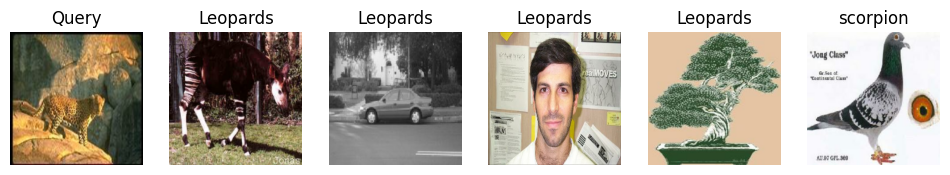

In [52]:
for images, labels in dataset.take(1):
    query_img = images[6]
    query_label = labels[6].numpy()

    indices = retrieve(query_img, top_k=5)

    show_results(query_img, indices, labels_db, class_names, dataset)

In [53]:
def precision_at_k(query_label, retrieved_labels, k):
    return np.sum(retrieved_labels[:k] == query_label) / k

In [54]:
def recall_at_k(query_label, retrieved_labels, all_labels, k):
    total_relevant = np.sum(all_labels == query_label)
    retrieved_relevant = np.sum(retrieved_labels[:k] == query_label)
    return retrieved_relevant / total_relevant

In [55]:
def average_precision(query_label, retrieved_labels):
    score = 0
    correct = 0

    for i in range(len(retrieved_labels)):
        if retrieved_labels[i] == query_label:
            correct += 1
            score += correct / (i + 1)

    # avoid division by zero
    if correct == 0:
        return 0

    return score / correct

In [56]:
def compute_map(dataset, num_samples=50):
    APs = []

    for images, labels in dataset.take(num_samples):
        for i in range(len(images)):
            query_img = images[i]
            query_label = labels[i].numpy()

            indices = retrieve(query_img, top_k=10)
            retrieved_labels = labels_db[indices]

            AP = average_precision(query_label, retrieved_labels)
            APs.append(AP)

    return np.mean(APs)

In [57]:
def add_noise(img):
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.1)
    return tf.clip_by_value(img + noise, 0.0, 1.0)

In [58]:
def compute_robustness(dataset):
    scores = []

    for images, labels in dataset.take(20):
        for i in range(len(images)):
            noisy = add_noise(images[i])
            query_label = labels[i].numpy()

            indices = retrieve(noisy, top_k=5)
            retrieved_labels = labels_db[indices]

            p = precision_at_k(query_label, retrieved_labels, 5)
            scores.append(p)

    return np.mean(scores)

In [59]:
precisions = []
recalls = []

for images, labels in dataset.take(20):
    for i in range(len(images)):
        query_img = images[i]
        query_label = labels[i].numpy()

        indices = retrieve(query_img, top_k=5)
        retrieved_labels = labels_db[indices]

        p = precision_at_k(query_label, retrieved_labels, 5)
        r = recall_at_k(query_label, retrieved_labels, labels_db, 5)

        precisions.append(p)
        recalls.append(r)

precision = np.mean(precisions)
recall = np.mean(recalls)
map_score = compute_map(dataset)
robustness = compute_robustness(dataset)

In [63]:
print("\nComparative Analysis\n")
print("{:<25} {:<10} {:<10} {:<10} {:<12} {:<15}".format(
    "Method", "Precision", "Recall", "mAP", "Robustness", "Remarks"))

print("-"*90)

print("{:<25} {:<10.3f} {:<10.3f} {:<10.3f} {:<12.3f} {:<15}".format(
    "Edge+Frequency+TextureFusion",
    precision,
    recall,
    map_score,
    robustness,
    "Proposed Method"
))


Comparative Analysis

Method                    Precision  Recall     mAP        Robustness   Remarks        
------------------------------------------------------------------------------------------
Edge+Frequency+TextureFusion 0.499      0.019      0.909      0.067        Proposed Method
